In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.model_selection import train_test_split
from tabulate import tabulate
from tqdm import tqdm

from scipy.ndimage import distance_transform_edt
from skimage.draw import polygon
from skimage.metrics import structural_similarity as ssim

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================
# 2. USER SETTINGS
# ============================================================
num_airfoils = 1250
grid_size = 256
airfoil_size = 92

test_size = 0.2
batch_size = 64
num_epochs = 325          # increase if you want stronger convergence
learning_rate = 1e-4

latent_dim = 100
fourier_mapping_size = 512
fourier_scale = 10.0

# training sizes to test
train_sizes = [50, 100, 200, 400, 600, 800, 1000]

# ============================================================
# 3. PLOTTING STYLE
# ============================================================
def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300

    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 12
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12

    mpl.rcParams['lines.linewidth'] = 2
    mpl.rcParams['lines.markersize'] = 6

    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5

    mpl.rcParams['image.cmap'] = 'plasma'

    plasma_cmap = mpl.cm.get_cmap('plasma')
    colors = [plasma_cmap(i) for i in np.linspace(0, 1, 10)]
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)

set_plot_params()

# ============================================================
# 4. METRICS
# ============================================================
def relative_l2_error_np(true, pred, eps=1e-12):
    num = np.linalg.norm((true - pred).ravel(), 2)
    den = np.linalg.norm(true.ravel(), 2) + eps
    return num / den

def compute_ssim_np(true, pred):
    data_range = true.max() - true.min()
    if data_range < 1e-12:
        data_range = 1.0
    return ssim(true, pred, data_range=data_range)

# ============================================================
# 5. DATASET GENERATION
# ============================================================
def naca4_series(m, p, t, num_points=100):
    x = np.linspace(0, 1, num_points)

    if p == 0:
        yc = np.zeros_like(x)
        dyc_dx = np.zeros_like(x)
    else:
        yc = np.where(
            x < p,
            (m / p**2) * (2 * p * x - x**2),
            (m / (1 - p)**2) * ((1 - 2 * p) + 2 * p * x - x**2)
        )
        dyc_dx = np.where(
            x < p,
            (2 * m / p**2) * (p - x),
            (2 * m / (1 - p)**2) * (p - x)
        )

    theta = np.arctan(dyc_dx)

    yt = 5 * t * (
        0.2969 * np.sqrt(np.clip(x, 1e-12, None))
        - 0.1260 * x
        - 0.3516 * x**2
        + 0.2843 * x**3
        - 0.1036 * x**4
    )

    xu = x - yt * np.sin(theta)
    xl = x + yt * np.sin(theta)
    yu = yc + yt * np.cos(theta)
    yl = yc - yt * np.cos(theta)

    X = np.concatenate((xu, xl[::-1]))
    Y = np.concatenate((yu, yl[::-1]))

    return X, Y

def airfoil_to_large_grid(x, y, grid_size=256, airfoil_size=128):
    x_scaled = (x - np.min(x)) / (np.max(x) - np.min(x)) * (airfoil_size - 1)
    y_scaled = (y - np.min(y)) / (np.max(y) - np.min(y)) * (airfoil_size - 1)

    x_shifted = x_scaled + (grid_size - airfoil_size) // 2
    y_shifted = y_scaled + (grid_size - airfoil_size) // 2

    x_shifted = np.clip(x_shifted, 0, grid_size - 1)
    y_shifted = np.clip(y_shifted, 0, grid_size - 1)

    img = np.ones((grid_size, grid_size), dtype=np.uint8)
    rr, cc = polygon(y_shifted, x_shifted, img.shape)
    img[rr, cc] = 0

    return img

def compute_signed_distance(airfoil_mask):
    sdf_outside = distance_transform_edt(airfoil_mask)
    sdf_inside = distance_transform_edt(1 - airfoil_mask)
    sdf = sdf_outside - sdf_inside

    max_abs = np.max(np.abs(sdf))
    if max_abs > 0:
        sdf = sdf / max_abs

    return sdf.astype(np.float32)

def generate_airfoil_dataset(num_airfoils, grid_size, airfoil_size):
    masks = np.zeros((num_airfoils, grid_size, grid_size), dtype=np.float32)
    sdfs = np.zeros((num_airfoils, grid_size, grid_size), dtype=np.float32)

    for i in tqdm(range(num_airfoils), desc="Generating NACA airfoils"):
        m = random.uniform(0.01, 0.09)
        p = random.uniform(0.1, 0.7)
        t = random.uniform(0.1, 0.4)

        x, y = naca4_series(m, p, t)
        mask = airfoil_to_large_grid(x, y, grid_size=grid_size, airfoil_size=airfoil_size)
        sdf = compute_signed_distance(mask)

        masks[i] = mask.astype(np.float32)
        sdfs[i] = sdf

    return masks, sdfs

print("Generating dataset...")
input_masks, target_sdfs = generate_airfoil_dataset(
    num_airfoils=num_airfoils,
    grid_size=grid_size,
    airfoil_size=airfoil_size
)
print("Dataset generation complete.")
print(f"Input masks shape: {input_masks.shape}")
print(f"Target SDF shape : {target_sdfs.shape}")

# ============================================================
# 6. FIXED TRAIN/TEST SPLIT
# ============================================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    input_masks,
    target_sdfs,
    test_size=test_size,
    random_state=42
)

print(f"Full train set: {X_train_full.shape[0]}")
print(f"Fixed test set: {X_test.shape[0]}")

# keep sizes valid
max_train = X_train_full.shape[0]
train_sizes = [n for n in train_sizes if n <= max_train]
print("Training sizes used:", train_sizes)

# ============================================================
# 7. DATASET CLASS
# ============================================================
class EikonalAirfoilDataset(Dataset):
    def __init__(self, masks, sdfs):
        self.masks = torch.tensor(masks, dtype=torch.float32).unsqueeze(1)
        self.sdfs = torch.tensor(sdfs, dtype=torch.float32).unsqueeze(1)

        self.grid_size = self.masks.shape[-1]
        grid = np.linspace(0.0, 1.0, self.grid_size, dtype=np.float32)
        X, Y = np.meshgrid(grid, grid, indexing='xy')
        coords = np.stack([X, Y], axis=-1)
        self.coords = torch.tensor(coords, dtype=torch.float32)

    def __len__(self):
        return self.masks.shape[0]

    def __getitem__(self, idx):
        return self.masks[idx], self.sdfs[idx]

test_dataset = EikonalAirfoilDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
coords = test_dataset.coords.to(device)

# ============================================================
# 8. MODEL DEFINITIONS
# ============================================================
class BranchNet(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

    def forward(self, x):
        return self.conv_layers(x)

class TrunkNet(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.fc_layers = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

    def forward(self, coords):
        return self.fc_layers(coords)

class DeepONet(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.branch_net = BranchNet(latent_dim=latent_dim)
        self.trunk_net = TrunkNet(latent_dim=latent_dim)

    def forward(self, masks, coords):
        batch_size = masks.size(0)
        H, W = coords.size(0), coords.size(1)

        coords_flat = coords.view(-1, 2)
        trunk_out = self.trunk_net(coords_flat)       # [H*W, p]
        branch_out = self.branch_net(masks)           # [B, p]

        outputs = torch.matmul(branch_out, trunk_out.T)
        outputs = outputs.view(batch_size, 1, H, W)
        return outputs

class FourierEmbedding(nn.Module):
    def __init__(self, input_dim=2, mapping_size=512, scale=10.0):
        super().__init__()
        B = torch.randn(input_dim, mapping_size) * scale
        self.register_buffer("B", B)

    def forward(self, x):
        x_proj = 2.0 * np.pi * x @ self.B
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class BranchNetFEDO(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

    def forward(self, x):
        return self.conv_layers(x)

class TrunkNetFEDO(nn.Module):
    def __init__(self, input_dim=2, latent_dim=100, mapping_size=512, scale=10.0):
        super().__init__()
        self.fourier_embed = FourierEmbedding(input_dim=input_dim, mapping_size=mapping_size, scale=scale)
        self.fc = nn.Sequential(
            nn.Linear(2 * mapping_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )

    def forward(self, x):
        x = self.fourier_embed(x)
        return self.fc(x)

class FEDONet(nn.Module):
    def __init__(self, input_dim=2, latent_dim=100, mapping_size=512, scale=10.0):
        super().__init__()
        self.branch_net = BranchNetFEDO(latent_dim=latent_dim)
        self.trunk_net = TrunkNetFEDO(
            input_dim=input_dim,
            latent_dim=latent_dim,
            mapping_size=mapping_size,
            scale=scale
        )

    def forward(self, masks, coords):
        batch_size = masks.size(0)
        H, W = coords.size(0), coords.size(1)

        coords_flat = coords.view(-1, 2)
        trunk_out = self.trunk_net(coords_flat)
        branch_out = self.branch_net(masks)

        outputs = torch.matmul(branch_out, trunk_out.T)
        outputs = outputs.view(batch_size, 1, H, W)
        return outputs

# ============================================================
# 9. TRAIN / EVAL FUNCTIONS
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, device, coords):
    model.train()
    running_loss = 0.0

    for masks, sdfs in loader:
        masks = masks.to(device)
        sdfs = sdfs.to(device)

        optimizer.zero_grad()
        pred = model(masks, coords)
        loss = criterion(pred, sdfs)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * masks.size(0)

    return running_loss / len(loader.dataset)

def evaluate_loss(model, loader, criterion, device, coords):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for masks, sdfs in loader:
            masks = masks.to(device)
            sdfs = sdfs.to(device)

            pred = model(masks, coords)
            loss = criterion(pred, sdfs)
            running_loss += loss.item() * masks.size(0)

    return running_loss / len(loader.dataset)

def evaluate_rel_l2(model, loader, device, coords):
    model.eval()
    rel_l2_list = []

    with torch.no_grad():
        for masks, sdfs in loader:
            masks = masks.to(device)
            sdfs = sdfs.to(device)

            preds = model(masks, coords)

            preds_np = preds.detach().cpu().numpy()
            sdfs_np = sdfs.detach().cpu().numpy()

            for i in range(preds_np.shape[0]):
                rel_l2_list.append(
                    relative_l2_error_np(sdfs_np[i, 0], preds_np[i, 0])
                )

    rel_l2_list = np.array(rel_l2_list)
    return float(np.mean(rel_l2_list)), float(np.std(rel_l2_list))

def build_train_loader_from_subset(X_train_full, y_train_full, subset_size, batch_size, seed=42):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(X_train_full), size=subset_size, replace=False)

    X_sub = X_train_full[indices]
    y_sub = y_train_full[indices]

    sub_dataset = EikonalAirfoilDataset(X_sub, y_sub)
    sub_loader = DataLoader(sub_dataset, batch_size=batch_size, shuffle=True)

    return sub_dataset, sub_loader

def train_model(model, train_loader, test_loader, coords, num_epochs, lr, device, tag="Model"):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_test_loss = float("inf")
    best_state = None

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, coords)
        test_loss = evaluate_loss(model, test_loader, criterion, device, coords)

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"{tag} | Epoch [{epoch+1:03d}/{num_epochs}] "
            f"| Train Loss: {train_loss:.8e} | Test Loss: {test_loss:.8e}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

# ============================================================
# 10. TRAINING-SIZE EXPERIMENT
# ============================================================
deeponet_means = []
deeponet_stds = []

fedonet_means = []
fedonet_stds = []

results_table = []

for n_train in train_sizes:
    print("\n" + "=" * 70)
    print(f"Training with {n_train} samples")
    print("=" * 70)

    # fixed subset for reproducibility
    train_dataset_sub, train_loader_sub = build_train_loader_from_subset(
        X_train_full, y_train_full, subset_size=n_train, batch_size=batch_size, seed=seed + n_train
    )

    coords_train = train_dataset_sub.coords.to(device)

    # DeepONet
    deeponet = DeepONet(latent_dim=latent_dim).to(device)
    deeponet = train_model(
        deeponet,
        train_loader_sub,
        test_loader,
        coords_train,
        num_epochs=num_epochs,
        lr=learning_rate,
        device=device,
        tag=f"DeepONet ({n_train})"
    )
    deep_mean, deep_std = evaluate_rel_l2(deeponet, test_loader, device, coords_train)

    # FEDONet
    fedonet = FEDONet(
        input_dim=2,
        latent_dim=latent_dim,
        mapping_size=fourier_mapping_size,
        scale=fourier_scale
    ).to(device)
    fedonet = train_model(
        fedonet,
        train_loader_sub,
        test_loader,
        coords_train,
        num_epochs=num_epochs,
        lr=learning_rate,
        device=device,
        tag=f"FEDONet  ({n_train})"
    )
    fedo_mean, fedo_std = evaluate_rel_l2(fedonet, test_loader, device, coords_train)

    deeponet_means.append(deep_mean)
    deeponet_stds.append(deep_std)

    fedonet_means.append(fedo_mean)
    fedonet_stds.append(fedo_std)

    results_table.append([
        n_train,
        deep_mean,
        deep_std,
        fedo_mean,
        fedo_std
    ])

# ============================================================
# 11. RESULTS TABLE
# ============================================================
print("\nEffect of number of training samples on test RelL2:\n")
print(tabulate(
    results_table,
    headers=[
        "Train Samples",
        "DeepONet Mean RelL2",
        "DeepONet Std",
        "FEDONet Mean RelL2",
        "FEDONet Std"
    ],
    floatfmt=".6f"
))

# ============================================================
# 12. PLOT: TRAINING SIZE VS RELATIVE L2 ERROR
# ============================================================
plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    deeponet_means,
    marker='o',
    linewidth=2,
    label='DeepONet'
)

plt.plot(
    train_sizes,
    fedonet_means,
    marker='s',
    linewidth=2,
    label='FEDONet'
)

plt.fill_between(
    train_sizes,
    np.array(deeponet_means) - np.array(deeponet_stds),
    np.array(deeponet_means) + np.array(deeponet_stds),
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    np.array(fedonet_means) - np.array(fedonet_stds),
    np.array(fedonet_means) + np.array(fedonet_stds),
    alpha=0.2
)

plt.xlabel("Number of training samples")
plt.ylabel("Mean Relative L2 Error")
plt.title("Effect of Training Set Size on Test Error")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 13. OPTIONAL: LOG-LOG PLOT
# ============================================================
plt.figure(figsize=(8, 5))

plt.loglog(
    train_sizes,
    deeponet_means,
    marker='o',
    linewidth=2,
    label='DeepONet'
)

plt.loglog(
    train_sizes,
    fedonet_means,
    marker='s',
    linewidth=2,
    label='FEDONet'
)

plt.xlabel("Number of training samples")
plt.ylabel("Mean Relative L2 Error")
plt.title("Sample Efficiency (Log-Log)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

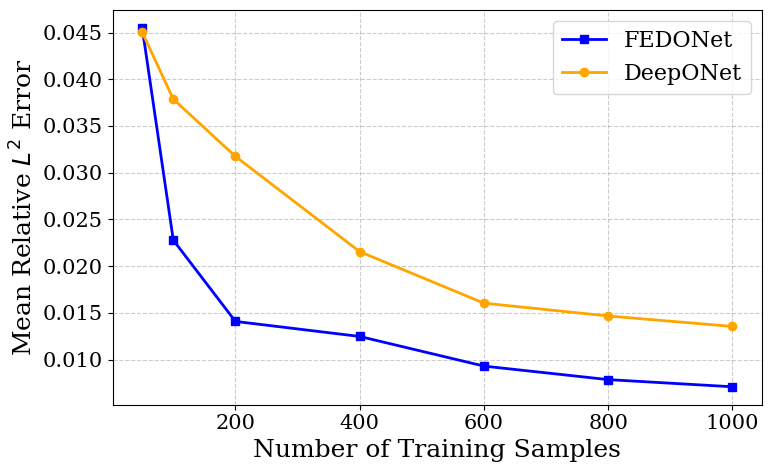

In [5]:
def set_plot_params():
    mpl.rcParams['figure.figsize'] = (8, 6)
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.size'] = 15
    mpl.rcParams['axes.titlesize'] = 16
    mpl.rcParams['axes.labelsize'] = 14
    mpl.rcParams['xtick.labelsize'] = 12
    mpl.rcParams['ytick.labelsize'] = 12
    mpl.rcParams['legend.fontsize'] = 12
    mpl.rcParams['grid.linestyle'] = '--'
    mpl.rcParams['grid.color'] = 'gray'
    mpl.rcParams['grid.alpha'] = 0.5
    mpl.rcParams['image.cmap'] = 'viridis'

set_plot_params()

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 21,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 16
})

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    fedonet_means,
    marker='s',
    color = 'blue',
    linewidth=2,
    label='FEDONet'
)

plt.plot(
    train_sizes,
    deeponet_means,
    marker='o',
    color = 'orange',
    linewidth=2,
    label='DeepONet'
)

plt.xlabel('Number of Training Samples')
plt.ylabel('Mean Relative $L^2$ Error')
# plt.title('Test Rel-L2 vs Fraction of Training Data', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()